In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED   = PROJECT_ROOT / "data" / "processed"
MATCHED_DIR = PROCESSED / "matched"

SEPHORA_COLOR = "#E91E63"
ULTA_COLOR    = "#9C27B0"
DIVERG_POS    = "#4CAF50"
DIVERG_NEG    = "#F44336"
NEUTRAL       = "#90A4AE"

In [2]:
sephora_df = pd.read_csv(PROCESSED / "Sephora" /"sephora_segmentation.csv",
                          dtype={"product_id": str})
ulta_df    = pd.read_csv(PROCESSED / "Ulta" / "ulta_segmentation.csv",
                          dtype={"product_id": str})
matched    = pd.read_csv(MATCHED_DIR / "matched_pairs.csv",
                          dtype={"sephora_product_id": str,
                                 "ulta_product_id":    str})

print(f"Sephora products : {len(sephora_df):,}")
print(f"Ulta products    : {len(ulta_df):,}")
print(f"Matched pairs    : {len(matched):,}")

# Confirm sentiment columns present
SENT_COLS = ["avg_sentiment", "pct_positive", "pct_negative", "pct_neutral"]
RATING_COLS = ["avg_rating", "rating_std", "pct_5_star", "pct_1_star",
               "rating_dispersion_over_time"]

for label, df in [("Sephora", sephora_df), ("Ulta", ulta_df)]:
    found   = [c for c in SENT_COLS + RATING_COLS if c in df.columns]
    missing = [c for c in SENT_COLS + RATING_COLS if c not in df.columns]
    print(f"\n{label} sentiment/rating cols found  : {found}")
    if missing:
        print(f"{label} missing                      : {missing}")

Sephora products : 1,632
Ulta products    : 11,227
Matched pairs    : 379

Sephora sentiment/rating cols found  : ['avg_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral', 'avg_rating', 'rating_std', 'pct_5_star', 'pct_1_star', 'rating_dispersion_over_time']

Ulta sentiment/rating cols found  : ['avg_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral', 'avg_rating', 'rating_std', 'pct_5_star', 'pct_1_star', 'rating_dispersion_over_time']


In [3]:
# Pull all sentiment + rating features for each side of every matched pair

FEATURES = [c for c in SENT_COLS + RATING_COLS
            if c in sephora_df.columns and c in ulta_df.columns]
print(f"\nShared features for comparison: {FEATURES}")

s_feat = sephora_df[["product_id"] + FEATURES].copy()
u_feat = ulta_df[  ["product_id"] + FEATURES].copy()

cross = (
    matched
    .merge(s_feat.add_suffix("_s").rename(columns={"product_id_s": "sephora_product_id"}),
           on="sephora_product_id", how="inner")
    .merge(u_feat.add_suffix("_u").rename(columns={"product_id_u": "ulta_product_id"}),
           on="ulta_product_id", how="inner")
)

# Compute per-pair deltas (Sephora − Ulta) for every feature
for f in FEATURES:
    cross[f"delta_{f}"] = (
        pd.to_numeric(cross[f"{f}_s"], errors="coerce") -
        pd.to_numeric(cross[f"{f}_u"], errors="coerce")
    )

print(f"\nCross-platform table: {len(cross):,} pairs × {len(cross.columns)} cols")
cross[["sephora_product_name", "ulta_product_name",
       "sephora_brand"] + [f"delta_{f}" for f in FEATURES]].head(5)


Shared features for comparison: ['avg_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral', 'avg_rating', 'rating_std', 'pct_5_star', 'pct_1_star', 'rating_dispersion_over_time']

Cross-platform table: 379 pairs × 47 cols


,sephora_product_name,ulta_product_name,sephora_brand,delta_avg_sentiment,delta_pct_positive,delta_pct_negative,delta_pct_neutral,delta_avg_rating,delta_rating_std,delta_pct_5_star,delta_pct_1_star,delta_rating_dispersion_over_time
0,Perfect Defense Heat Protectant - Moroccanoil,Perfect Defense Heat Protectant - 6.0 oz,Moroccanoil,-0.131492,-0.087239,0.066545,0.020694,-0.475756,0.581400,-0.188071,0.047677,-0.516823
1,All in One Leave-In Conditioner - Moroccanoil,All in One Leave-In Conditioner,Moroccanoil,-0.228429,-0.083305,0.100503,-0.017197,-0.671468,0.790083,-0.248576,0.095477,-0.137972
2,Hydrating Shampoo - Moroccanoil,Hydrating Shampoo - 8.5 oz,Moroccanoil,-0.146473,-0.044129,0.048774,-0.004645,-0.794779,0.438866,-0.252323,0.101821,-1.096206
3,Hydrating Conditioner - Moroccanoil,Hydrating Conditioner - 8.5 oz,Moroccanoil,-0.028337,-0.001831,-0.008009,0.009840,-0.439130,0.603621,-0.099085,0.067735,-1.192325
4,Liquid Glass Smoothing Shampoo - Drybar,Liquid Glass Smoothing Shampoo - 8.5 oz,Drybar,-0.047094,-0.027778,0.013228,0.014550,-0.338624,0.208284,-0.111111,0.041005,-1.058842


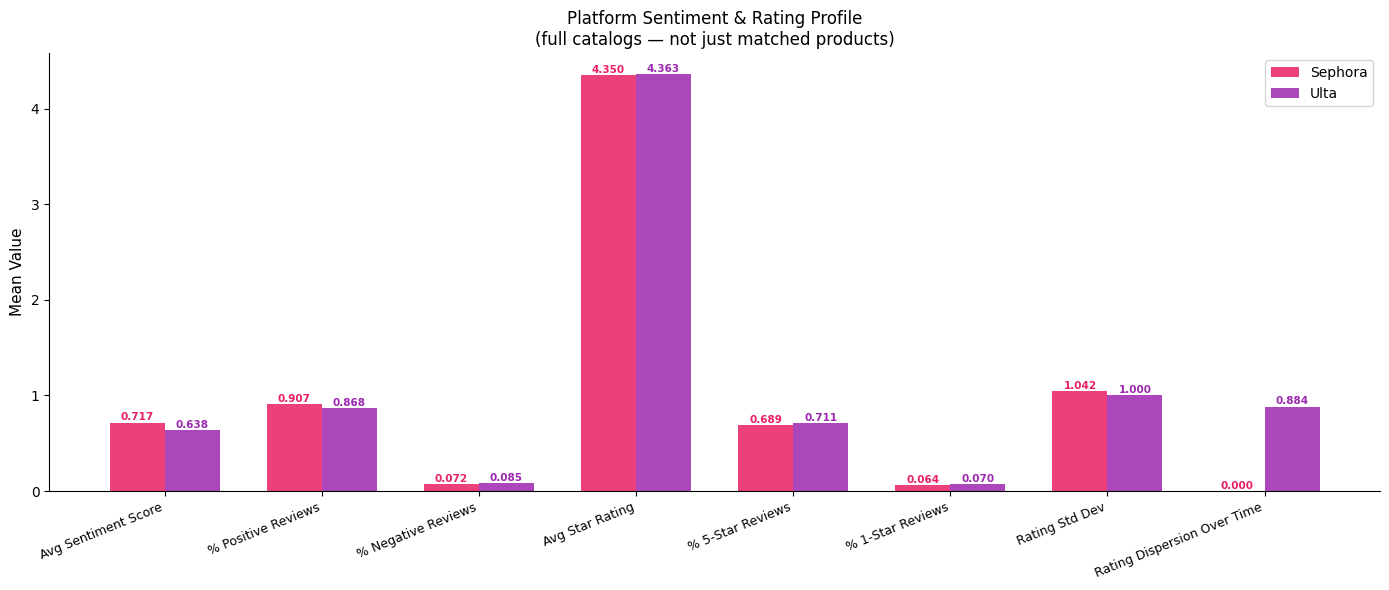

In [4]:
# Side-by-side bar comparison of key sentiment/rating metrics

display_metrics = {
    "avg_sentiment":              "Avg Sentiment Score",
    "pct_positive":               "% Positive Reviews",
    "pct_negative":               "% Negative Reviews",
    "avg_rating":                 "Avg Star Rating",
    "pct_5_star":                 "% 5-Star Reviews",
    "pct_1_star":                 "% 1-Star Reviews",
    "rating_std":                 "Rating Std Dev",
    "rating_dispersion_over_time":"Rating Dispersion Over Time",
}
available = {k: v for k, v in display_metrics.items()
             if k in sephora_df.columns and k in ulta_df.columns}

s_vals = [sephora_df[k].mean() for k in available]
u_vals = [ulta_df[k].mean()    for k in available]
labels = list(available.values())

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_s = ax.bar(x - width/2, s_vals, width, color=SEPHORA_COLOR, alpha=0.85,
                label="Sephora")
bars_u = ax.bar(x + width/2, u_vals, width, color=ULTA_COLOR,    alpha=0.85,
                label="Ulta")

# Annotate bars
for bar in bars_s:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=7.5, color=SEPHORA_COLOR, fontweight="bold")
for bar in bars_u:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=7.5, color=ULTA_COLOR, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=22, ha="right", fontsize=9)
ax.set_ylabel("Mean Value", fontsize=11)
ax.set_title("Platform Sentiment & Rating Profile\n"
             "(full catalogs — not just matched products)", fontsize=12)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_platform_profile.png",
            dpi=150, bbox_inches="tight")
plt.show()

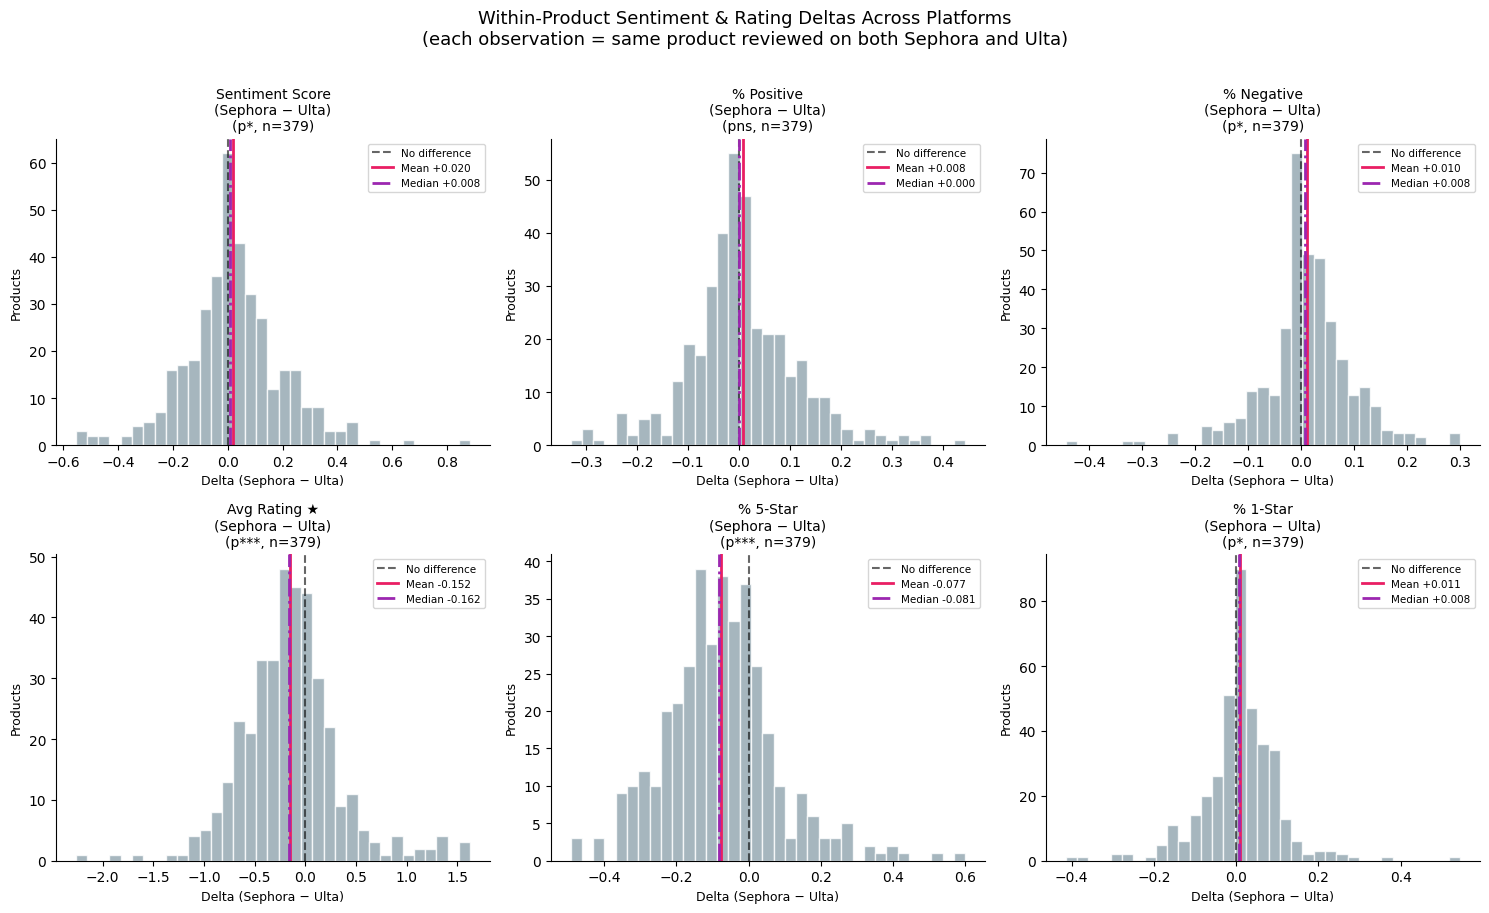

In [5]:
# For the same physical products: how does sentiment/rating differ by channel?

delta_display = {
    "delta_avg_sentiment": "Sentiment Score\n(Sephora − Ulta)",
    "delta_pct_positive":  "% Positive\n(Sephora − Ulta)",
    "delta_pct_negative":  "% Negative\n(Sephora − Ulta)",
    "delta_avg_rating":    "Avg Rating ★\n(Sephora − Ulta)",
    "delta_pct_5_star":    "% 5-Star\n(Sephora − Ulta)",
    "delta_pct_1_star":    "% 1-Star\n(Sephora − Ulta)",
}
available_deltas = {k: v for k, v in delta_display.items() if k in cross.columns}
n_plots = len(available_deltas)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes_flat = axes.flatten() if n_plots > 1 else [axes]

for i, (col, title) in enumerate(available_deltas.items()):
    ax  = axes_flat[i]
    arr = cross[col].dropna().values

    ax.hist(arr, bins=35, color=NEUTRAL, edgecolor="white", alpha=0.8)
    ax.axvline(0,         color="black",    lw=1.5, ls="--", alpha=0.6,
               label="No difference")
    ax.axvline(arr.mean(), color=SEPHORA_COLOR, lw=2, ls="-",
               label=f"Mean {arr.mean():+.3f}")
    ax.axvline(np.median(arr), color=ULTA_COLOR, lw=2, ls="-.",
               label=f"Median {np.median(arr):+.3f}")

    # One-sample t-test: is the mean significantly different from 0?
    t_stat, p_val = stats.ttest_1samp(arr[~np.isnan(arr)], 0)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else \
          "*" if p_val < 0.05 else "ns"
    ax.set_title(f"{title}\n(p{sig}, n={len(arr)})", fontsize=10)
    ax.legend(fontsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Delta (Sephora − Ulta)", fontsize=9)
    ax.set_ylabel("Products", fontsize=9)

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Within-Product Sentiment & Rating Deltas Across Platforms\n"
             "(each observation = same product reviewed on both Sephora and Ulta)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_delta_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [6]:
print("=" * 60)
print("  Within-Product Sentiment Gap — Statistical Summary")
print("=" * 60)
print(f"  n = {len(cross):,} matched pairs\n")

for col, title in available_deltas.items():
    arr = cross[col].dropna().values
    if len(arr) == 0:
        continue
    t_stat, p_val = stats.ttest_1samp(arr, 0)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else \
          "*" if p_val < 0.05 else "ns"
    seph_higher = (arr > 0).mean()
    label = title.replace("\n", " ")
    print(f"  {label:<35} mean={arr.mean():+.4f}  "
          f"median={np.median(arr):+.4f}  "
          f"Sephora>Ulta: {seph_higher:.1%}  "
          f"p={p_val:.4f}{sig}")

  Within-Product Sentiment Gap — Statistical Summary
  n = 379 matched pairs

  Sentiment Score (Sephora − Ulta)    mean=+0.0203  median=+0.0082  Sephora>Ulta: 54.6%  p=0.0308*
  % Positive (Sephora − Ulta)         mean=+0.0076  median=+0.0000  Sephora>Ulta: 48.8%  p=0.1734ns
  % Negative (Sephora − Ulta)         mean=+0.0104  median=+0.0076  Sephora>Ulta: 55.7%  p=0.0187*
  Avg Rating ★ (Sephora − Ulta)       mean=-0.1524  median=-0.1616  Sephora>Ulta: 31.1%  p=0.0000***
  % 5-Star (Sephora − Ulta)           mean=-0.0771  median=-0.0812  Sephora>Ulta: 24.8%  p=0.0000***
  % 1-Star (Sephora − Ulta)           mean=+0.0106  median=+0.0079  Sephora>Ulta: 55.4%  p=0.0276*


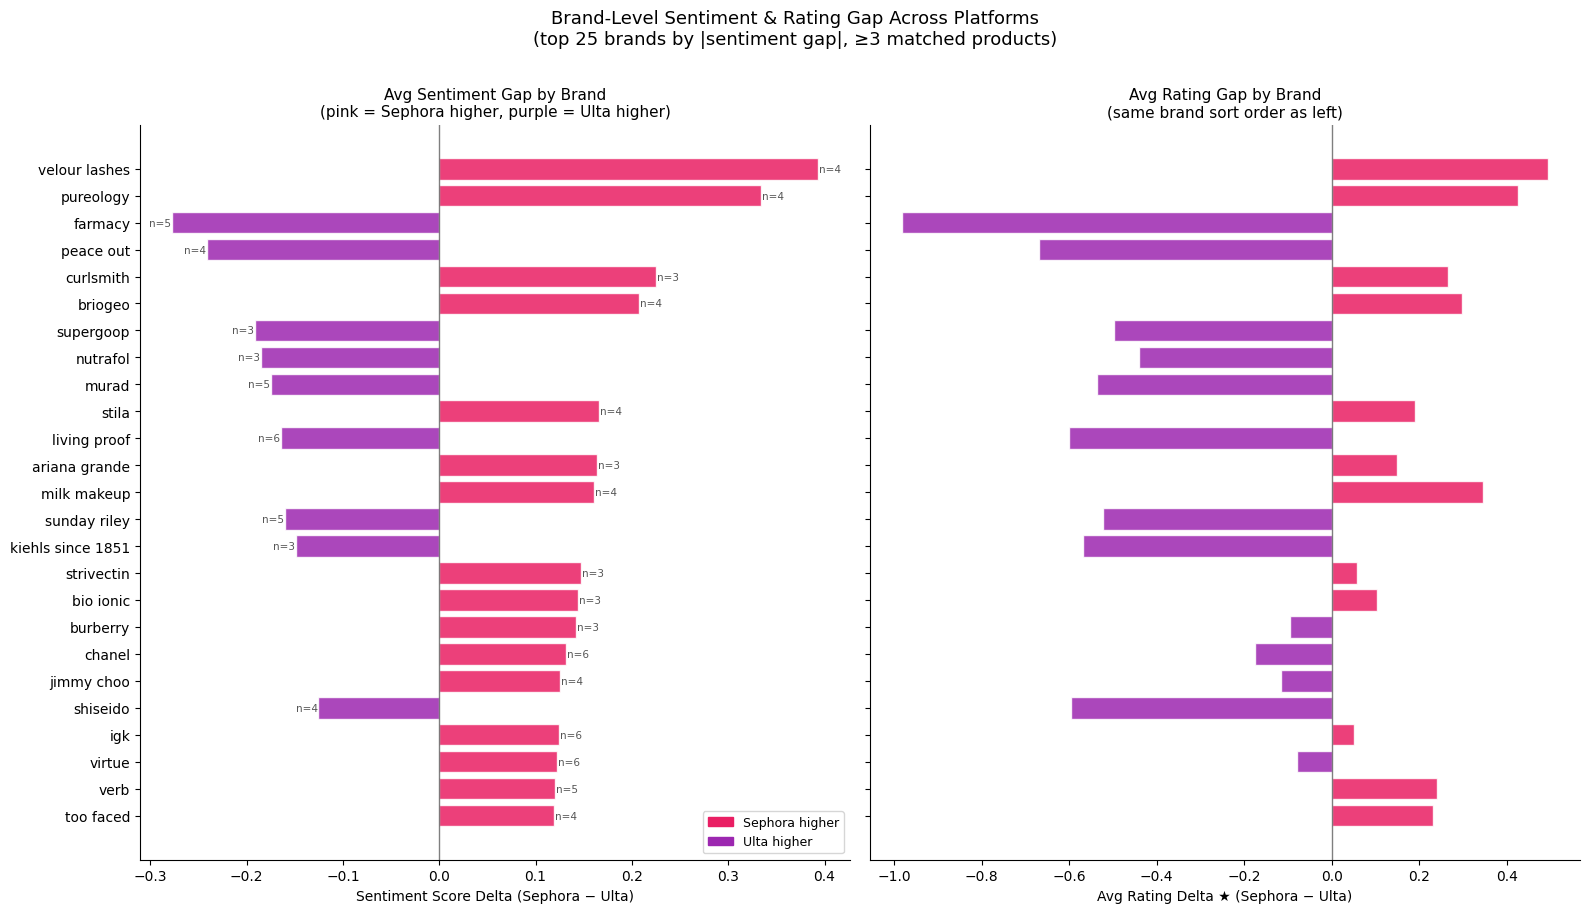

In [7]:
# Which brands show the largest consistent sentiment divergence by channel?

brand_deltas = (
    cross
    .groupby("sephora_brand_normalized")
    .agg(
        n                   = ("sephora_product_id", "count"),
        mean_sentiment_gap  = ("delta_avg_sentiment", "mean"),
        mean_rating_gap     = ("delta_avg_rating",    "mean"),
        mean_pos_gap        = ("delta_pct_positive",  "mean"),
        mean_neg_gap        = ("delta_pct_negative",  "mean"),
        pct_sephora_higher_rating = ("delta_avg_rating",
                                     lambda x: (x > 0).mean()),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

# Focus on brands with ≥ 3 matched products for reliability
brand_plot = brand_deltas[brand_deltas["n"] >= 3].copy()

# Sort by absolute sentiment gap for the chart
brand_plot = brand_plot.reindex(
    brand_plot["mean_sentiment_gap"].abs().sort_values(ascending=True).index
).tail(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left: avg sentiment delta
colors_sent = [SEPHORA_COLOR if v > 0 else ULTA_COLOR
               for v in brand_plot["mean_sentiment_gap"]]
bars = axes[0].barh(brand_plot["sephora_brand_normalized"],
                    brand_plot["mean_sentiment_gap"],
                    color=colors_sent, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, brand_plot.itertuples()):
    axes[0].text(
        bar.get_width() + (0.001 if bar.get_width() >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f"n={row.n}", va="center", ha="left" if bar.get_width() >= 0 else "right",
        fontsize=7.5, color="#555"
    )
axes[0].axvline(0, color="black", lw=1, alpha=0.5)
axes[0].set_xlabel("Sentiment Score Delta (Sephora − Ulta)", fontsize=10)
axes[0].set_title("Avg Sentiment Gap by Brand\n"
                  f"(pink = Sephora higher, purple = Ulta higher)",
                  fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: avg rating delta (same sort order)
colors_rat = [SEPHORA_COLOR if v > 0 else ULTA_COLOR
              for v in brand_plot["mean_rating_gap"]]
axes[1].barh(brand_plot["sephora_brand_normalized"],
             brand_plot["mean_rating_gap"],
             color=colors_rat, alpha=0.85, edgecolor="white")
axes[1].axvline(0, color="black", lw=1, alpha=0.5)
axes[1].set_xlabel("Avg Rating Delta ★ (Sephora − Ulta)", fontsize=10)
axes[1].set_title("Avg Rating Gap by Brand\n(same brand sort order as left)",
                  fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].set_yticklabels([])   # avoid duplicate labels

legend_items = [
    mpatches.Patch(color=SEPHORA_COLOR, label="Sephora higher"),
    mpatches.Patch(color=ULTA_COLOR,    label="Ulta higher"),
]
axes[0].legend(handles=legend_items, fontsize=9, loc="lower right")

fig.suptitle("Brand-Level Sentiment & Rating Gap Across Platforms\n"
             "(top 25 brands by |sentiment gap|, ≥3 matched products)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_brand_sentiment_gap.png",
            dpi=150, bbox_inches="tight")
plt.show()

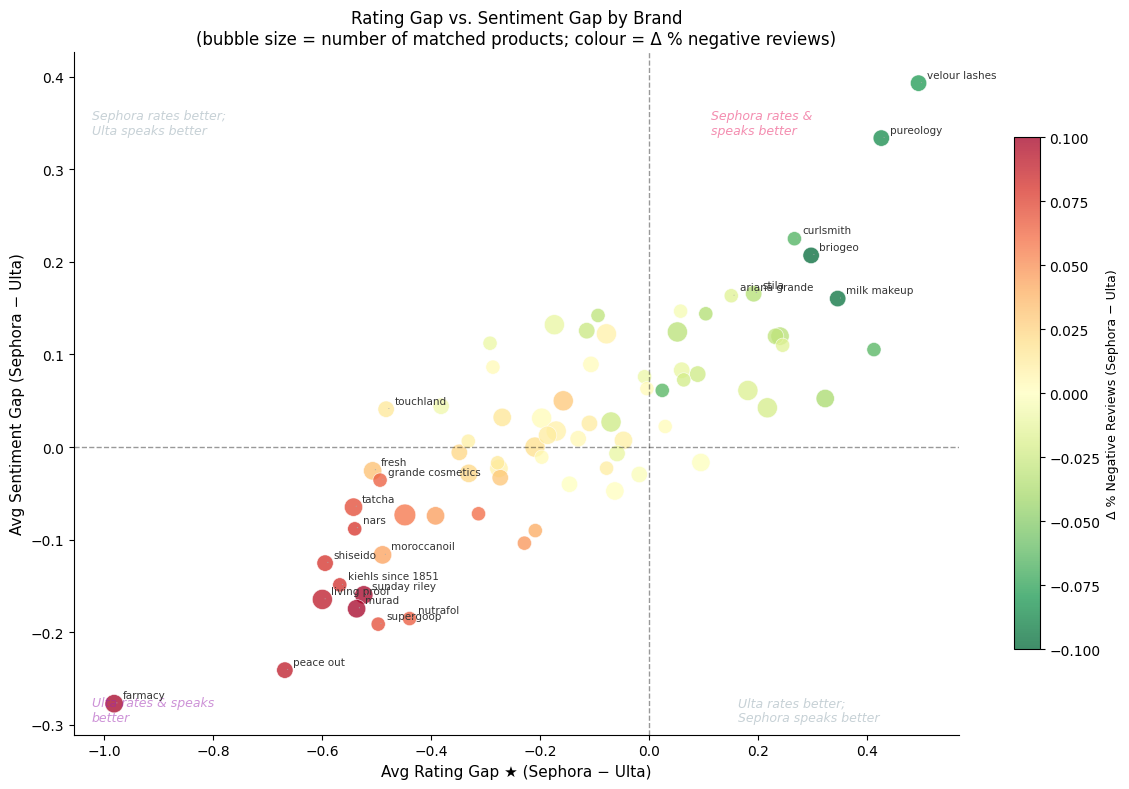

In [8]:
# Are sentiment gaps and rating gaps correlated?
# Quadrants reveal: rating gap alone vs. language gap alone vs. both vs. neither

fig, ax = plt.subplots(figsize=(12, 8))

plot_df = brand_deltas[brand_deltas["n"] >= 3].dropna(
    subset=["mean_sentiment_gap", "mean_rating_gap"]
)

scatter = ax.scatter(
    plot_df["mean_rating_gap"],
    plot_df["mean_sentiment_gap"],
    s=plot_df["n"] * 35,
    c=plot_df["mean_neg_gap"],
    cmap="RdYlGn_r",
    alpha=0.75, edgecolors="white", linewidths=0.5,
    vmin=-0.1, vmax=0.1,
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
cbar.set_label("Δ % Negative Reviews (Sephora − Ulta)", fontsize=9)

ax.axvline(0, color="black", lw=1, ls="--", alpha=0.4)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.4)

# Quadrant labels
q_style = dict(fontsize=9, alpha=0.5, style="italic")
ax.text( 0.02,  0.02, "Ulta rates & speaks\nbetter",
         transform=ax.transAxes, color=ULTA_COLOR, **q_style)
ax.text( 0.75,  0.02, "Ulta rates better;\nSephora speaks better",
         transform=ax.transAxes, color=NEUTRAL, **q_style)
ax.text( 0.02,  0.88, "Sephora rates better;\nUlta speaks better",
         transform=ax.transAxes, color=NEUTRAL, **q_style)
ax.text( 0.72,  0.88, "Sephora rates &\nspeaks better",
         transform=ax.transAxes, color=SEPHORA_COLOR, **q_style)

# Label outlier brands
threshold_r = plot_df["mean_rating_gap"].abs().quantile(0.80)
threshold_s = plot_df["mean_sentiment_gap"].abs().quantile(0.80)
label_mask  = ((plot_df["mean_rating_gap"].abs()    > threshold_r) |
               (plot_df["mean_sentiment_gap"].abs() > threshold_s))

for _, row in plot_df[label_mask].iterrows():
    ax.annotate(
        row["sephora_brand_normalized"],
        xy=(row["mean_rating_gap"], row["mean_sentiment_gap"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=7.5, color="#333",
        arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.7),
    )

ax.set_xlabel("Avg Rating Gap ★ (Sephora − Ulta)", fontsize=11)
ax.set_ylabel("Avg Sentiment Gap (Sephora − Ulta)", fontsize=11)
ax.set_title(
    "Rating Gap vs. Sentiment Gap by Brand\n"
    "(bubble size = number of matched products; colour = Δ % negative reviews)",
    fontsize=12,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_gap_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()

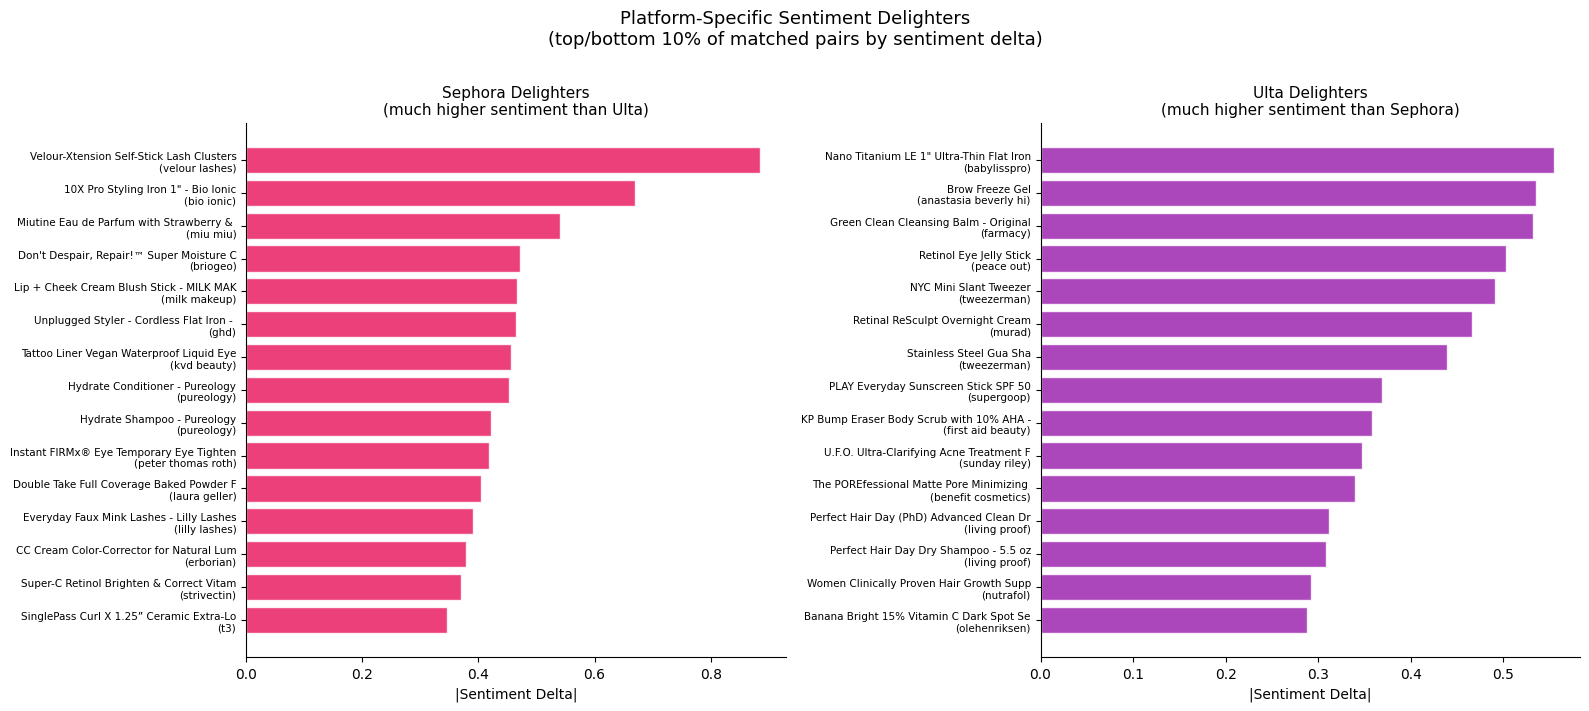

In [9]:
# Products where one platform dramatically outperforms the other on sentiment

if "delta_avg_sentiment" in cross.columns:
    q_hi = cross["delta_avg_sentiment"].quantile(0.90)
    q_lo = cross["delta_avg_sentiment"].quantile(0.10)

    sephora_delighters = (cross[cross["delta_avg_sentiment"] >= q_hi]
                          [["sephora_product_name", "sephora_brand_normalized",
                            "delta_avg_sentiment", "delta_avg_rating",
                            "sephora_price", "ulta_price"]]
                          .sort_values("delta_avg_sentiment", ascending=False)
                          .head(15))

    ulta_delighters = (cross[cross["delta_avg_sentiment"] <= q_lo]
                       [["ulta_product_name", "sephora_brand_normalized",
                         "delta_avg_sentiment", "delta_avg_rating",
                         "sephora_price", "ulta_price"]]
                       .sort_values("delta_avg_sentiment")
                       .head(15))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, df, col, color, title, prefix in [
        (axes[0], sephora_delighters, "delta_avg_sentiment",
         SEPHORA_COLOR, "Sephora Delighters\n(much higher sentiment than Ulta)",
         "sephora_product_name"),
        (axes[1], ulta_delighters,    "delta_avg_sentiment",
         ULTA_COLOR,    "Ulta Delighters\n(much higher sentiment than Sephora)",
         "ulta_product_name"),
    ]:
        labels_bar = (df[prefix].str[:40] + "\n(" +
                      df["sephora_brand_normalized"].str[:20] + ")")
        vals = df[col].abs().values
        ax.barh(labels_bar[::-1], vals[::-1], color=color, alpha=0.85,
                edgecolor="white")
        ax.set_xlabel("|Sentiment Delta|", fontsize=10)
        ax.set_title(title, fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="y", labelsize=7.5)

    fig.suptitle("Platform-Specific Sentiment Delighters\n"
                 "(top/bottom 10% of matched pairs by sentiment delta)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_platform_delighters.png",
                dpi=150, bbox_inches="tight")
    plt.show()

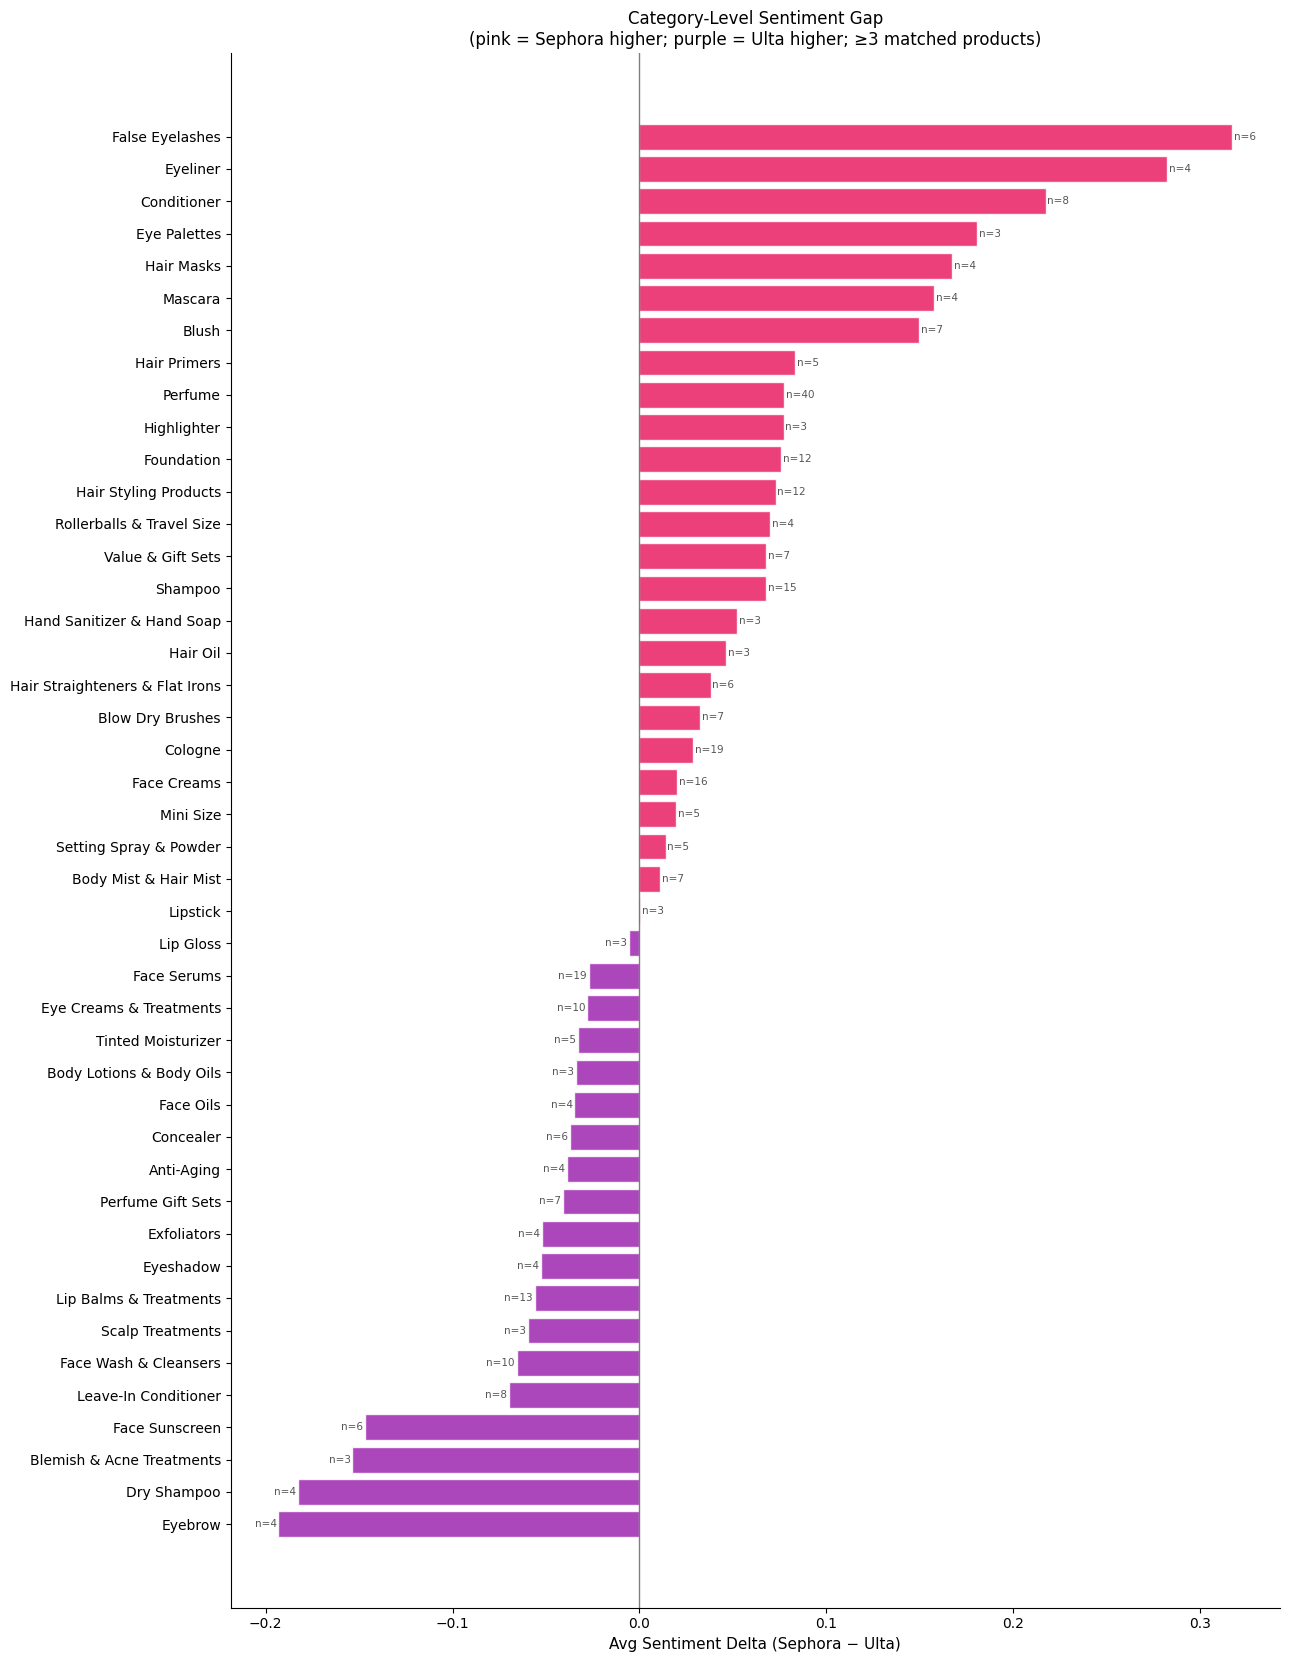

In [10]:
# Load category from sephora_df to enrich cross

cross_cat = cross.merge(
    sephora_df[["product_id", "category"]].rename(
        columns={"product_id": "sephora_product_id", "category": "s_category"}
    ),
    on="sephora_product_id", how="left"
)

cat_sentiment = (
    cross_cat
    .groupby("s_category")
    .agg(
        n               = ("sephora_product_id", "count"),
        mean_sent_delta = ("delta_avg_sentiment", "mean"),
        mean_rat_delta  = ("delta_avg_rating",    "mean"),
        mean_neg_delta  = ("delta_pct_negative",  "mean"),
    )
    .query("n >= 3")
    .sort_values("mean_sent_delta")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, max(6, len(cat_sentiment) * 0.38)))

colors_cat = [SEPHORA_COLOR if v > 0 else ULTA_COLOR
              for v in cat_sentiment["mean_sent_delta"]]
bars = ax.barh(cat_sentiment["s_category"],
               cat_sentiment["mean_sent_delta"],
               color=colors_cat, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, cat_sentiment.itertuples()):
    ax.text(
        bar.get_width() + (0.001 if bar.get_width() >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f"n={row.n}", va="center",
        ha="left" if bar.get_width() >= 0 else "right",
        fontsize=7.5, color="#555"
    )

ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("Avg Sentiment Delta (Sephora − Ulta)", fontsize=11)
ax.set_title("Category-Level Sentiment Gap\n"
             "(pink = Sephora higher; purple = Ulta higher; ≥3 matched products)",
             fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.3_category_sentiment_gap.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("  2.3  SENTIMENT GAP ANALYSIS — SUMMARY")

if "delta_avg_sentiment" in cross.columns:
    arr = cross["delta_avg_sentiment"].dropna().values
    t, p = stats.ttest_1samp(arr, 0)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"\nSentiment delta (Sephora − Ulta) across {len(arr):,} matched products:")
    print(f"  Mean   : {arr.mean():+.4f}")
    print(f"  Median : {np.median(arr):+.4f}")
    print(f"  Sephora higher sentiment : {(arr > 0).mean():.1%} of products")
    print(f"  Ulta higher sentiment    : {(arr < 0).mean():.1%} of products")
    print(f"  t-test vs 0              : t={t:.3f}, p={p:.4f} ({sig})")

if "delta_avg_rating" in cross.columns:
    arr = cross["delta_avg_rating"].dropna().values
    t, p = stats.ttest_1samp(arr, 0)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"\nRating delta (Sephora − Ulta) across {len(arr):,} matched products:")
    print(f"  Mean   : {arr.mean():+.4f} ★")
    print(f"  Median : {np.median(arr):+.4f} ★")
    print(f"  Sephora higher rating : {(arr > 0).mean():.1%} of products")
    print(f"  Ulta higher rating    : {(arr < 0).mean():.1%} of products")
    print(f"  t-test vs 0           : t={t:.3f}, p={p:.4f} ({sig})")

print(f"\nBrands analysed (≥3 matched products): "
      f"{len(brand_deltas[brand_deltas['n'] >= 3])}")

top3_seph = brand_deltas[brand_deltas["n"] >= 3].nlargest(3, "mean_sentiment_gap")
top3_ulta = brand_deltas[brand_deltas["n"] >= 3].nsmallest(3, "mean_sentiment_gap")

print("\nBrands most favoured on Sephora (highest +sentiment gap):")
for _, r in top3_seph.iterrows():
    print(f"  {r['sephora_brand_normalized']:<35} "
          f"Δsentiment={r['mean_sentiment_gap']:+.4f}  "
          f"Δrating={r['mean_rating_gap']:+.4f}  n={r['n']}")

print("\nBrands most favoured on Ulta (lowest sentiment gap):")
for _, r in top3_ulta.iterrows():
    print(f"  {r['sephora_brand_normalized']:<35} "
          f"Δsentiment={r['mean_sentiment_gap']:+.4f}  "
          f"Δrating={r['mean_rating_gap']:+.4f}  n={r['n']}")

  2.3  SENTIMENT GAP ANALYSIS — SUMMARY

Sentiment delta (Sephora − Ulta) across 379 matched products:
  Mean   : +0.0203
  Median : +0.0082
  Sephora higher sentiment : 54.6% of products
  Ulta higher sentiment    : 45.4% of products
  t-test vs 0              : t=2.168, p=0.0308 (*)

Rating delta (Sephora − Ulta) across 379 matched products:
  Mean   : -0.1524 ★
  Median : -0.1616 ★
  Sephora higher rating : 31.1% of products
  Ulta higher rating    : 68.3% of products
  t-test vs 0           : t=-6.081, p=0.0000 (***)

Brands analysed (≥3 matched products): 75

Brands most favoured on Sephora (highest +sentiment gap):
  velour lashes                       Δsentiment=+0.3930  Δrating=+0.4939  n=4
  pureology                           Δsentiment=+0.3336  Δrating=+0.4256  n=4
  curlsmith                           Δsentiment=+0.2250  Δrating=+0.2662  n=3

Brands most favoured on Ulta (lowest sentiment gap):
  farmacy                             Δsentiment=-0.2772  Δrating=-0.9816  n=5
 

## Cross-Platform Sentiment and Rating Gap Analysis

### Platform-Level Baseline Profiles

The full-catalog comparison establishes the platform baselines against which matched-product gaps should be interpreted. Sephora's average sentiment score (0.717) exceeds Ulta's (0.638), and Sephora's positive review rate (90.7%) is higher than Ulta's (86.8%), while Sephora's negative review rate (7.2%) is lower than Ulta's (8.5%). At the platform level, Sephora reviews are more positive in expressed sentiment than Ulta reviews. Yet Sephora's average star rating (4.350) is marginally lower than Ulta's (4.363), and Sephora has a lower 5-star rate (68.9% vs. 71.1%) and slightly higher 1-star rate (6.4% vs. 7.0%). Sephora also shows higher rating standard deviation (1.042 vs. 1.000), confirming greater rating dispersion even against a slightly lower mean.

This apparent contradiction — Sephora reviews are more positive in language but lower in numerical star rating — reflects a structural difference in how the two platforms' consumers express evaluation. Sephora reviewers use more positive language in review text while applying more demanding numerical rating standards; Ulta reviewers are more generous with star ratings but less effusive in written sentiment. The two signals are measuring partially different things, and the divergence between them is itself a characterization of each platform's review culture.

### Within-Product Sentiment and Rating Deltas

The within-product analysis — restricted to the 379 matched pairs where the same SKU appears on both platforms — isolates the platform contribution to consumer response from product-level variation. The statistical results are asymmetric across the two primary signals.

Sentiment score shows a small but statistically significant Sephora advantage: mean delta of +0.020, median +0.008, with 54.6% of products receiving higher sentiment at Sephora (p = 0.031). The magnitude is modest and the distribution is wide — the sentiment delta histogram spans roughly −0.6 to +0.9 with substantial product-level variance — but the directional lean is consistent and reaches significance. Sephora's text sentiment is marginally higher for the same product on average. The negative review rate delta corroborates this in the other direction: Sephora generates slightly more negative reviews proportionally (mean delta +0.010, p = 0.019), which is superficially inconsistent with higher overall sentiment scores but reflects the composition of Sephora's review activity — a community that is both more effusively positive about products it loves and more explicitly critical about products that disappoint, producing higher variance across both ends of the sentiment distribution simultaneously.

The percentage-positive delta is not significant (p = 0.173), meaning that the binary classification of reviews as positive or negative does not reliably differ across platforms for the same product. The significant signals are in the continuous sentiment score and in the star rating distributions, not in coarse positive-negative categorization.

Star ratings tell an unambiguously different story. The average rating delta is −0.152 stars (median −0.162 stars), with Ulta rating higher on 68.3% of matched products — significant at p < 0.001 with a t-statistic of −6.08. The 5-star rate is lower on Sephora by 7.7 percentage points on average (p < 0.001), and the 1-star rate is higher on Sephora by 1.1 percentage points (p = 0.028). Together these three measures describe a consistent picture: Sephora consumers apply stricter numerical rating standards to the same products, awarding fewer 5-star ratings and more 1-star ratings, resulting in a systematically lower average star rating regardless of product category or brand. This is a platform-level calibration effect, not a product quality signal, and its consistency across 68% of matched pairs confirms it is structural rather than driven by a minority of anomalous products.

### Brand-Level Gaps: Two Distinct Patterns

The brand-level chart and rating-versus-sentiment scatter reveal two structurally distinct brand groups, visible in the four-quadrant positioning of the bubble chart.

The upper-right quadrant — Sephora rates and speaks better — contains the brands most positively differentiated at Sephora: Velour Lashes (+0.39 sentiment, +0.49 rating), Pureology (+0.33 sentiment, +0.43 rating), Curlsmith (+0.23 sentiment, +0.27 rating), Briogeo (+0.20 sentiment, +0.34 rating), and Milk Makeup (+0.16 sentiment, +0.35 rating). These brands share a profile: professional or performance-oriented haircare brands (Pureology, Curlsmith, Briogeo) and clean-beauty innovators (Milk Makeup, Velour Lashes) whose Sephora consumer communities are more aligned with their brand positioning than Ulta's broader base. Pureology and Curlsmith are professional haircare brands whose Sephora consumers are specifically seeking performance haircare in a prestige context, making them more likely to evaluate against high but appropriate expectations. Velour Lashes' extreme positive Sephora advantage (+0.39 sentiment) reflects its positioning as a premium lash brand whose Sephora consumer is exactly the target demographic — engaged, beauty-focused, willing to invest in professional-grade lash products.

The lower-left quadrant — Ulta rates and speaks better — contains the brands with the largest Sephora disadvantage. Farmacy (−0.28 sentiment, −0.98 rating) and Peace Out (−0.24 sentiment, −0.67 rating) are the most extreme cases, followed by Supergoop (−0.19 sentiment, −0.50 rating), Living Proof (−0.15 sentiment, −0.43 rating), Sunday Riley (−0.14 sentiment, −0.53 rating), Kiehl's (−0.13 sentiment, −0.65 rating), Murad (−0.17 sentiment, −0.43 rating), and Shiseido (−0.12 sentiment, −0.62 rating). The lower-left cluster is predominantly functional skincare — acne treatments, active ingredient serums, sunscreens, anti-aging formulas — where Sephora's informed consumer base has higher efficacy expectations and is more likely to critically evaluate performance claims. Farmacy's nearly one-star rating gap (−0.98) is the most extreme in the entire matched set and signals a product-expectation mismatch specifically at Sephora, where the brand's clean-ingredient positioning may attract consumers with higher performance expectations than its formulations consistently deliver. The red coloring of these bubbles in the scatter — indicating higher negative review rates at Sephora — confirms that the lower-left cluster brands are generating disproportionate negative review activity at Sephora relative to their Ulta performance.

The upper-left quadrant — Sephora rates better but Ulta speaks better in text — is sparsely populated, with only a few brands near the axes. This combination is rare because rating and sentiment gaps are generally correlated: platforms that rate higher also tend to produce more positive written sentiment for the same products.

### Category-Level Sentiment Patterns

The category sentiment gap chart provides the most granular structural view of where Sephora and Ulta consumer responses systematically diverge. False Eyelashes and Eyeliner show the largest Sephora-favoring gaps (approximately +0.30 to +0.35 sentiment delta), followed by Conditioner, Eye Palettes, Hair Masks, Mascara, and Blush — all categories with strong Sephora enthusiast communities and clearly defined performance expectations. The false eyelashes and eye makeup result is consistent with the Velour Lashes brand-level finding: Sephora's beauty-specialist consumer base evaluates eye enhancement products with higher appreciation relative to Ulta's more general consumer.

The Ulta-favoring categories are predominantly functional skincare and treatment products: Eyebrow products, Dry Shampoo, Blemish and Acne Treatments, Face Sunscreen, Leave-In Conditioner, and Face Wash and Cleansers all show negative sentiment deltas, meaning the same products in these categories receive more positive written sentiment from Ulta consumers than from Sephora consumers. The pattern is coherent: functional skincare categories attract more demanding, efficacy-focused evaluation at Sephora, where consumers in these categories are more likely to be comparing against a broader set of prestige alternatives and holding products to higher performance standards. At Ulta, the same product in a functional skincare category is evaluated against a wider price range including mass and drugstore alternatives, making a mid-tier functional product appear more favorably positioned.

Perfume (n=40, the largest matched category) shows a moderate Sephora-favoring sentiment gap of approximately +0.10, consistent with Sephora's stronger fragrance community and the platform's role as a primary fragrance discovery channel. With 40 matched fragrance products this is the most statistically robust category-level finding in the chart, and the direction — Sephora consumers express more positive fragrance sentiment — is consistent with the platform's historical positioning as the prestige fragrance destination.

### Platform-Specific Delighters

The delighter analysis — top and bottom 10% of matched pairs by absolute sentiment delta — identifies the products where platform context has the largest individual-product effect. Sephora delighters are led by Velour-Xtension Self-Stick Lash Clusters (delta +0.85, by far the largest in the set), Bio Ionic's 10X Pro Styling Iron (+0.65), and Miu Miu's Miutine Eau de Parfum (+0.55). Beyond the lash cluster result, the Sephora delighters span tools, makeup, and haircare — products where Sephora's community of engaged beauty consumers evaluates performance with specialist appreciation that Ulta's broader base does not match.

Ulta delighters are led by BaBylissPRO's Nano Titanium Flat Iron (+0.55), Anastasia Beverly Hills Brow Freeze Gel (+0.53), Farmacy's Green Clean Cleansing Balm (+0.53), and Peace Out's Retinal Eye Jelly Stick (+0.52). The Ulta delighter list is dominated by professional tools and functional skincare — precisely the categories identified as Ulta-favoring in the category sentiment chart. BaBylissPRO's flat iron receiving dramatically higher Ulta sentiment is consistent with Ulta's professional haircare positioning and its consumer base's familiarity with professional tool brands. Anastasia's Brow Freeze receiving higher Ulta sentiment reflects the product's positioning in a more broadly accessible consumer context at Ulta, where it is evaluated as a high-performance brow product against a mass-to-prestige reference set rather than exclusively against Sephora's premium brow category peers. The presence of Farmacy and Peace Out in both the Ulta delighter list and the lower-left quadrant of the brand scatter confirms that these brands' platform dynamics are driven primarily by their functional skincare portfolios rather than brand-level effects.